# Анализ тональности постов Twitter

В рамках итоговой работы необходимо разработать систему анализа тональности русскоязычных постов Twitter. Основная задача заключается в том, чтобы определить эмоциональную окраску текста на основе методов обработки естественного языка и машинного обучения.

Для решения поставленной задачи используются два размеченных датасета: набор позитивных и набор негативных сообщений. На первых этапах работы проводится подготовка данных, очистка текстов, тематический анализ и преобразование текстовой информации в числовой вид для дальнейшего обучения моделей машинного обучения.

## 1. Необходимые поля и структура набора данных

### Загрузка библиотек

In [1]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

### Загрузка датасетов

Положительные и отрицательные посты хранятся в отдельных CSV-файлах. Изначально файлы не содержат названий столбцов, поэтому необходимо задать их вручную.

In [2]:
fields = [
    'tweet_id',
    'publish_date',
    'author',
    'message',
    'sentiment_type',
    'answer_count',
    'repost_count',
    'likes_count',
    'subscriber_count',
    'subscription_count',
    'collection_count',
    'posts_total'
]

### Чтение датасетов

In [3]:
positive_posts = pd.read_csv(
    'pos.csv',
    sep=';',
    names=fields,
    header=None
)

negative_posts = pd.read_csv(
    'neg.csv',
    sep=';',
    names=fields,
    header=None
)

### Добавление целевого признака

In [4]:
positive_posts['target'] = 1
negative_posts['target'] = 0

Для обучения модели необходимо перевести тональность в числовой формат:

1 — положительное сообщение;
0 — отрицательное сообщение.

### Объединение датасетов

In [5]:
twitter_df = pd.concat(
    [positive_posts, negative_posts],
    ignore_index=True
)

In [6]:
print(twitter_df.shape)

(226834, 13)


### Просмотр структуры данных

In [7]:
twitter_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 226834 entries, 0 to 226833
Data columns (total 13 columns):
 #   Column              Non-Null Count   Dtype 
---  ------              --------------   ----- 
 0   tweet_id            226834 non-null  int64 
 1   publish_date        226834 non-null  int64 
 2   author              226834 non-null  object
 3   message             226834 non-null  object
 4   sentiment_type      226834 non-null  int64 
 5   answer_count        226834 non-null  int64 
 6   repost_count        226834 non-null  int64 
 7   likes_count         226834 non-null  int64 
 8   subscriber_count    226834 non-null  int64 
 9   subscription_count  226834 non-null  int64 
 10  collection_count    226834 non-null  int64 
 11  posts_total         226834 non-null  int64 
 12  target              226834 non-null  int64 
dtypes: int64(11), object(2)
memory usage: 22.5+ MB


In [8]:
twitter_df.sample(5)

,tweet_id,publish_date,author,message,sentiment_type,answer_count,repost_count,likes_count,subscriber_count,subscription_count,collection_count,posts_total,target
64640,410360973951000576,1386672654,IlgizValinurov,Заглянул в новый офис Ритейл пипл. Как видите ...,1,0,0,0,3115,27,3,3,1
43767,409969643193786368,1386579354,AxoBix,@BlizzardCSEU_RU Здраствуй Ватя! Солнечного ут...,1,0,0,0,46,1,16,0,1
132027,411201103624421376,1386872957,98_irka,"я несу бред , не обращайте внимания. Пойду спа...",-1,0,0,0,363,18,14,0,0
14663,409339990670577664,1386429233,abrikos30,RT @JustMironspace: Какая совершенная правда ;...,1,0,21,0,2980,412,686,0,1
199064,420432992247369728,1389074011,arina_matveeva_,"Кошмар время пол 4,я только глаза открыла(",-1,0,0,0,226,10,5,0,0


После загрузки датасета было обнаружено, что столбец с датой содержит некорректный формат данных.

In [9]:
twitter_df[['publish_date']].head()

,publish_date
0,1386325927
1,1386325927
2,1386325927
3,1386325927
4,1386325943


### Преобразование даты

In [10]:
twitter_df['publish_date'] = pd.to_datetime(
    twitter_df['publish_date'],
    unit='s'
)

In [11]:
twitter_df[['publish_date']].head()

,publish_date
0,2013-12-06 10:32:07
1,2013-12-06 10:32:07
2,2013-12-06 10:32:07
3,2013-12-06 10:32:07
4,2013-12-06 10:32:23


### Анализ признаков

В исходном датасете присутствует большое количество столбцов, связанных с активностью пользователей Twitter.

- tweet_id - идентификатор публикации
- publish_date - дата публикации
- author - имя пользователя
- message	- текст поста
- sentiment_type - исходная метка тональности
- answer_count - количество ответов
- repost_count - количество репостов
- likes_count - количество лайков
- subscriber_count - число подписчиков
- subscription_count - число подписок
- collection_count - число списков
- posts_total - общее количество постов

Однако основным источником информации для определения эмоциональной окраски является именно текст сообщения.
Числовые показатели активности пользователя могут характеризовать популярность аккаунта или поста, но напрямую не определяют настроение текста.
Поэтому для дальнейшего анализа были оставлены только:

- текст сообщения;
- целевая переменная.

Остальные признаки были исключены.

### Формирование итогового набора данных

In [12]:
twitter_df = twitter_df[['message', 'target']]

In [13]:
twitter_df.head()

,message,target
0,"@first_timee хоть я и школота, но поверь, у на...",1
1,"Да, все-таки он немного похож на него. Но мой ...",1
2,RT @KatiaCheh: Ну ты идиотка) я испугалась за ...,1
3,"RT @digger2912: ""Кто то в углу сидит и погибае...",1
4,@irina_dyshkant Вот что значит страшилка :D\nН...,1


### Проверка пропущенных значений

In [14]:
twitter_df.isnull().sum()

message    0
target     0
dtype: int64

### Анализ баланса классов

In [15]:
twitter_df['target'].value_counts()

target
1    114911
0    111923
Name: count, dtype: int64

Визуализируем распределение классов

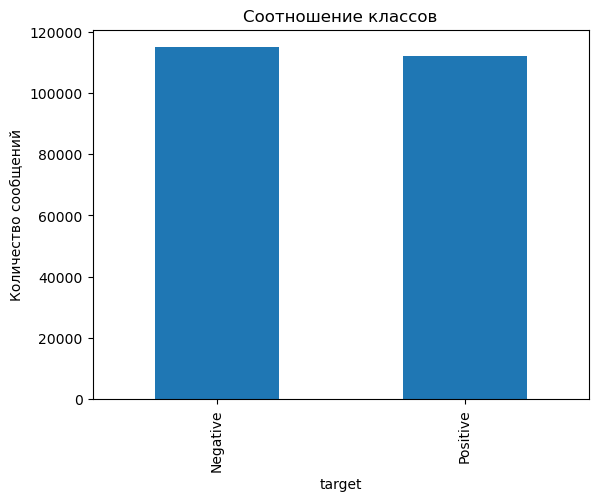

In [16]:
import matplotlib.pyplot as plt
twitter_df['target'].value_counts().plot(kind='bar')

plt.xticks([0, 1], ['Negative', 'Positive'])
plt.title('Соотношение классов')
plt.ylabel('Количество сообщений')
plt.show()

Вывод по этапу 1

На первом этапе были загружены и объединены два набора данных с русскоязычными сообщениями Twitter.

После анализа структуры датасета было установлено, что главным признаком для определения тональности является непосредственно текст публикации. Остальные признаки характеризуют активность пользователя и статистику аккаунта, поэтому для дальнейшего обучения модели они не используются.

В результате был сформирован упрощенный датафрейм, содержащий только текст сообщения и метку класса.
Также была проведена проверка пропусков и анализ распределения положительных и отрицательных сообщений.

## Предварительная обработка текстов

In [17]:
import re
import nltk
import pymorphy3

from nltk.corpus import stopwords
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\darina\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [22]:
morph_analyzer = pymorphy3.MorphAnalyzer()
russian_stopwords = set(stopwords.words('russian'))

### Создание функции очистки текста

In [30]:
import re
import pymorphy3
from nltk.corpus import stopwords

morph = pymorphy3.MorphAnalyzer()

stop_words = set(stopwords.words('russian'))

# слова-паразиты
extra_stopwords = {

    'это', 'весь', 'который', 'свой', 'ещё',
    'очень', 'сегодня', 'завтра', 'просто',
    'вообще', 'почему', 'твой', 'мой',
    'наш', 'ваш', 'самый', 'сам',

    'мочь', 'хотеть', 'знать',
    'сказать', 'сделать', 'всё',
    'пока', 'давать', 'кстати', 'rt',

    'день', 'год', 'человек', 'время',
    'идти', 'делать', 'думать',
    'пойти', 'писать', 'смотреть',
    'первый', 'новый', 'говорить',
    'ждать', 'дом', 'жизнь', 'час'
}

stop_words.update(extra_stopwords)

def clean_text(text):
    text = str(text).lower()
    # ссылки
    text = re.sub(r'http\\S+', ' ', text)
    # упоминания
    text = re.sub(r'@\\w+', ' ', text)
    # хештеги
    text = re.sub(r'#\\w+', ' ', text)
    # цифры
    text = re.sub(r'\\d+', ' ', text)
    # только русские буквы
    text = re.sub(r'[^а-яё\\s]', ' ', text)
    # удаляем лишние пробелы
    text = re.sub(r'\\s+', ' ', text).strip()
    words = text.split()
    cleaned_words = []
    
    for word in words:
        # убираем короткие слова
        if len(word) < 3:
            continue
        # убираем стоп-слова
        if word in stop_words:
            continue

        lemma = morph.parse(word)[0].normal_form

        # снова проверяем после лемматизации
        if lemma not in stop_words and len(lemma) >= 3:
            cleaned_words.append(lemma)

    return ' '.join(cleaned_words)

twitter_df['clean_text'] = twitter_df['message'].apply(clean_text)

### Применение очистки к датасету

In [31]:
twitter_df['clean_text'] = twitter_df['message'].apply(clean_text)

In [32]:
twitter_df[['message', 'clean_text']].sample(10)

,message,clean_text
204473,Урааа! По компам экзамен на 5!!! Живопись и ри...,урааа комп экзамен живопись рисунок узнавать
197860,;( я его никогда не собиру http://t.co/FjpEpwICqI,собира
133189,"Все сидят, отдыхают, а я учу для Тёмы истори...",сидеть отдыхать учить тёма история
106860,"Завтра я вряд ли говорить смогу,голосу постепе...",вряд смочь голос постепенно приходить конец ка...
19317,@El_Mad_bro ахиренно застелил на альбом Дислер...,ахиренно застелить альбом дислера взлетать бро...
80091,"Эй, сплетницы, кем зависть движет! \nКому прив...",сплетница зависть двигать привычно хребет чеса...
93967,@im_so_fae хоть какая то с него польза ;) поп ...,польза поп корн готовый слушать
13976,RT @kolebanovaP: Кому пованговать???\n-% лени\...,пованговать лень упоротость единорожество цвет...
160079,"@taasechkaa капецц ваще,а если нет,ну это прос...",капецца ващий ссорить мат
14921,"RT @dajosuvuvir: Помните игру ""Города""? Вот on...",помнить игра город версия играться


### Удаление пустых сообщений

In [33]:
twitter_df = twitter_df[
    twitter_df['clean_text'].str.strip() != ''
]

print('Размер датасета после очистки:')
print(twitter_df.shape)

Размер датасета после очистки:
(225486, 3)


### Анализ наиболее частых слов

In [34]:
from collections import Counter

# позитивные
positive_words = ' '.join(
    twitter_df[twitter_df['target'] == 1]['clean_text']
).split()

# негативные
negative_words = ' '.join(
    twitter_df[twitter_df['target'] == 0]['clean_text']
).split()

positive_freq = Counter(positive_words)
negative_freq = Counter(negative_words)

print('ТОП-20 слов позитивных сообщений:')
print(positive_freq.most_common(20))

print('\\nТОП-20 слов негативных сообщений:')
print(negative_freq.most_common(20))

ТОП-20 слов позитивных сообщений:
[('спасибо', 3680), ('любить', 3380), ('хороший', 3183), ('друг', 2065), ('утро', 1897), ('добрый', 1733), ('сидеть', 1556), ('любимый', 1499), ('спать', 1483), ('написать', 1471), ('ахи', 1402), ('посмотреть', 1356), ('ночь', 1356), ('настроение', 1340), ('видеть', 1320), ('мама', 1257), ('школа', 1256), ('понять', 1229), ('ахах', 1228), ('нравиться', 1221)]
\nТОП-20 слов негативных сообщений:
[('блин', 3280), ('любить', 2263), ('спать', 2215), ('болеть', 2179), ('школа', 1931), ('сидеть', 1851), ('хотеться', 1693), ('настроение', 1673), ('мама', 1622), ('скучать', 1564), ('никто', 1525), ('утро', 1462), ('плохо', 1447), ('последний', 1437), ('жаль', 1413), ('работа', 1359), ('хороший', 1358), ('друг', 1353), ('стать', 1246), ('неделя', 1194)]


Вывод по этапу 2

На этапе предварительной обработки были очищены все тексты датасета.
Из сообщений были удалены ссылки, специальные символы, цифры, упоминания пользователей и лишние пробелы.
После этого тексты были приведены к нижнему регистру, а слова — к начальной форме с помощью лемматизации.
Дополнительно были удалены стоп-слова русского языка, не несущие смысловой нагрузки.

## 3. Тематическое моделирование и анализ словаря

### Облако слов для положительных сообщений

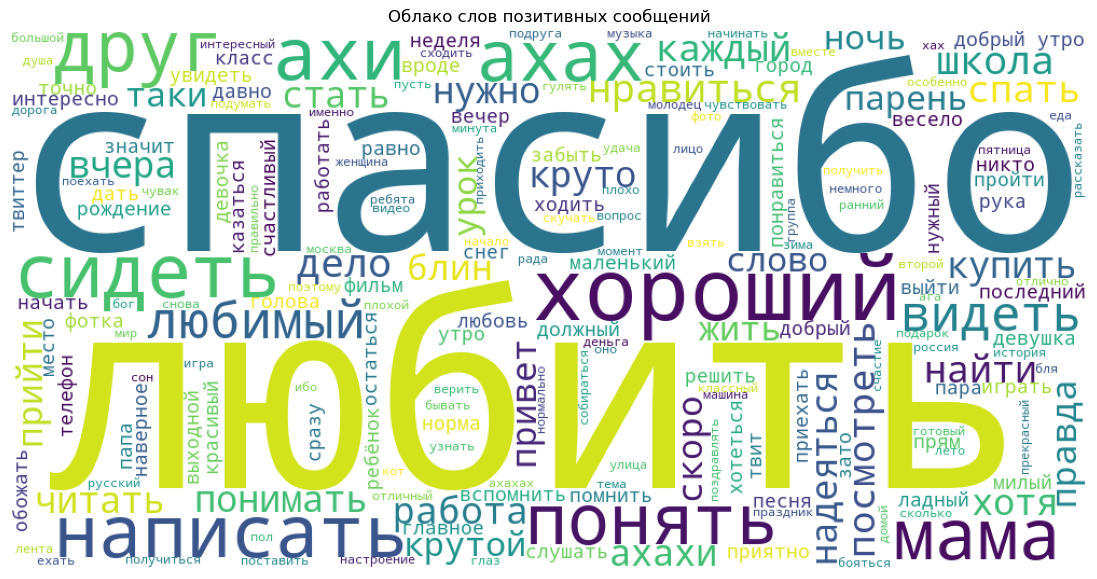

In [35]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

positive_text = ' '.join(
    twitter_df[twitter_df['target'] == 1]['clean_text']
)

wordcloud_pos = WordCloud(
    width=1000,
    height=500,
    background_color='white'
).generate(positive_text)

plt.figure(figsize=(14, 7))
plt.imshow(wordcloud_pos)
plt.axis('off')
plt.title('Облако слов позитивных сообщений')
plt.show()

### Облако слов для негативных сообщений

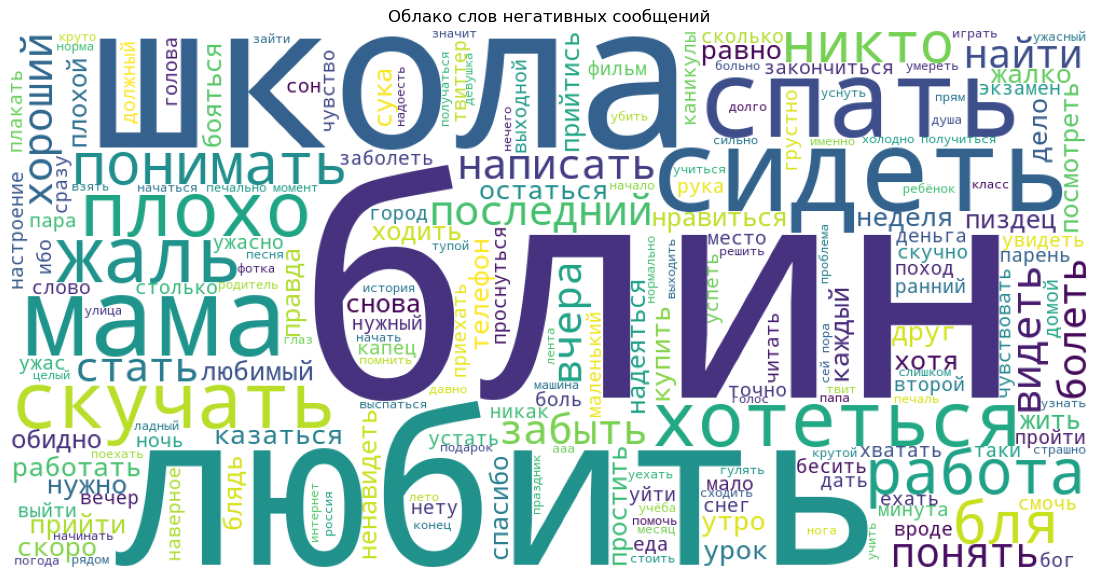

In [37]:
negative_text = ' '.join(
    twitter_df[twitter_df['target'] == 0]['clean_text']
)

wordcloud_neg = WordCloud(
    width=1000,
    height=500,
    background_color='white'
).generate(negative_text)

plt.figure(figsize=(14, 7))
plt.imshow(wordcloud_neg)
plt.axis('off')
plt.title('Облако слов негативных сообщений')
plt.show()

После очистки текста различия между положительными и отрицательными сообщениями стали более заметны.

В положительных сообщениях чаще встречаются слова:
- «спасибо»;
- «хороший»;
- «добрый»;
- «любимый».

В негативных сообщениях чаще встречаются слова:
- «блин»;
- «болеть»;
- «плохо»;
- «скучать».

Это показывает, что предобработка текста была выполнена корректно и данные подходят для дальнейшей классификации тональности.

In [38]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

### Создание матрицы Bag of Words для LDA

In [41]:
count_vectorizer = CountVectorizer(
    max_features=1000,
    min_df=10,
    max_df=0.8
)

X_counts = count_vectorizer.fit_transform(
    twitter_df['clean_text']
)

### Обучение LDA

In [42]:
lda_model = LatentDirichletAllocation(
    n_components=3,
    random_state=42,
    learning_method='online'
)

lda_model.fit(X_counts)

LatentDirichletAllocation(learning_method='online', n_components=3,
                          random_state=42)

### Вывод тем

In [43]:
feature_names = count_vectorizer.get_feature_names_out()

for topic_idx, topic in enumerate(lda_model.components_):

    print(f'\nТема #{topic_idx + 1}')

    top_words = [
        feature_names[i]
        for i in topic.argsort()[:-11:-1]
    ]

    print(', '.join(top_words))


Тема #1
хороший, сидеть, настроение, утро, скучать, последний, любимый, плохо, прийти, жаль

Тема #2
блин, любить, друг, спасибо, никто, работа, написать, видеть, посмотреть, ночь

Тема #3
спать, школа, болеть, мама, хотеться, стать, дело, купить, урок, бля


- Тема 1 - настроение/эмоции;
- Тема 2 - общение;
- Тема 3 - школа/усталость/болезнь.

### Обучение NMF

In [44]:
from sklearn.decomposition import NMF
from sklearn.feature_extraction.text import TfidfVectorizer

In [46]:
tfidf_nmf = TfidfVectorizer(
    max_features=1000,
    min_df=10,
    max_df=0.8
)

X_tfidf_nmf = tfidf_nmf.fit_transform(
    twitter_df['clean_text']
)

In [47]:
nmf_model = NMF(
    n_components=3,
    random_state=42
)

nmf_model.fit(X_tfidf_nmf)

NMF(n_components=3, random_state=42)

### Вывод тем

In [48]:
feature_names_nmf = tfidf_nmf.get_feature_names_out()

for topic_idx, topic in enumerate(nmf_model.components_):

    print(f'\nТема #{topic_idx + 1}')

    top_words = [
        feature_names_nmf[i]
        for i in topic.argsort()[:-11:-1]
    ]

    print(', '.join(top_words))


Тема #1
любить, любимый, сильно, никто, скучать, зима, друг, видеть, понимать, любовь

Тема #2
спасибо, большой, приятно, любимый, вечер, читать, огромный, милый, ахи, прекрасный

Тема #3
хороший, блин, спать, утро, настроение, школа, добрый, сидеть, друг, мама


- Тема 1 связана с эмоциями, отношениями и личными переживаниями пользователей. В сообщениях часто встречаются слова, связанные с любовью, дружбой и тоской.
- Тема 2 отражает положительные эмоции и благодарность. Пользователи чаще используют слова с позитивной эмоциональной окраской.
- Тема 3 связана с повседневной жизнью пользователей: учебой, усталостью, режимом дня и бытовыми событиями.

По сравнению с LDA, модель NMF показала более интерпретируемые темы.

Темы NMF лучше разделяют эмоциональные группы сообщений, так как модель использует TF-IDF представление текстов.

Для коротких текстов Twitter NMF показала более качественный результат тематического моделирования.

## 4. Векторизация текста

## Bag of Words

In [49]:
from sklearn.feature_extraction.text import CountVectorizer

bow_vectorizer = CountVectorizer(
    max_features=5000,
    min_df=2
)

X_bow = bow_vectorizer.fit_transform(
    twitter_df['clean_text']
)

print('Размер матрицы Bag of Words:')
print(X_bow.shape)

Размер матрицы Bag of Words:
(225486, 5000)


### Словарь признаков

In [51]:
bow_features = bow_vectorizer.get_feature_names_out()
print(bow_features[:20])

['sss' 'ssss' 'ааа' 'аааа' 'ааааа' 'аааааа' 'ааааааа' 'аааааааа' 'аахи'
 'абсолютно' 'ава' 'авария' 'аватар' 'аватарка' 'август' 'авто' 'автобус'
 'автограф' 'автомат' 'автомобиль']


### Часть матрицы

In [52]:
import pandas as pd

bow_df = pd.DataFrame(
    X_bow[:5].toarray(),
    columns=bow_features
)

bow_df.iloc[:, :15]

,sss,ssss,ааа,аааа,ааааа,аааааа,ааааааа,аааааааа,аахи,абсолютно,ава,авария,аватар,аватарка,август
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


## TF-IDF

In [53]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vectorizer = TfidfVectorizer(
    max_features=5000,
    min_df=2
)

X_tfidf = tfidf_vectorizer.fit_transform(
    twitter_df['clean_text']
)

print('Размер матрицы TF-IDF:')
print(X_tfidf.shape)

Размер матрицы TF-IDF:
(225486, 5000)


### Словарь признаков

In [54]:
tfidf_features = tfidf_vectorizer.get_feature_names_out()

print(tfidf_features[:20])

['sss' 'ssss' 'ааа' 'аааа' 'ааааа' 'аааааа' 'ааааааа' 'аааааааа' 'аахи'
 'абсолютно' 'ава' 'авария' 'аватар' 'аватарка' 'август' 'авто' 'автобус'
 'автограф' 'автомат' 'автомобиль']


### Часть матрицы

In [55]:
tfidf_df = pd.DataFrame(
    X_tfidf[:5].toarray(),
    columns=tfidf_features
)

tfidf_df.iloc[:, :15]

,sss,ssss,ааа,аааа,ааааа,аааааа,ааааааа,аааааааа,аахи,абсолютно,ава,авария,аватар,аватарка,август
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### Сравнение размеров

In [56]:
print('Bag of Words:', X_bow.shape)
print('TF-IDF:', X_tfidf.shape)

Bag of Words: (225486, 5000)
TF-IDF: (225486, 5000)
